In [1]:
import warnings
# warnings.filterwarnings('ignore')
import torch
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
import json
import pandas as pd
import datetime
today = datetime.date.today()
import pickle
import arviz as az
from arviz.utils import get_coords, _var_names

from flonacomldft.utils.io_utils import (
    load_csv_file,
    load_pickle_file,
)
from flonacomldft.models.mixture import Mixture

from flonacomldft.utils.diagnostics import R_hat

from flonacomldft.free_energy_computations import (
    compute_BAR_from_samples, compute_TFP_from_samples
)
from ase.units import kB



In [2]:
import seaborn as sns
sns.set()

# science format
science = {
            # Set line widths
            'axes.linewidth' : 1,
            'grid.linewidth' : 1,

            # Remove legend frame
            #'legend.frameon' : False,

            # Always save as 'tight'
            'savefig.bbox' : 'tight',
            'savefig.pad_inches' : 0.05,

            # Use serif fonts
            # 'font.serif' : 'Times',
            'font.family' : 'serif',
            'mathtext.fontset' : 'dejavuserif',
    
            # Set y axis
            'ytick.direction' : 'out',
            'ytick.major.size' : 3,
            'ytick.major.width' : 0.5,
            'ytick.minor.size' : 1.5,
            'ytick.minor.width' : 0.5,
            'ytick.minor.visible' : False,

            # Set x axis
            'xtick.direction' : 'out',
            'xtick.major.size' : 3,
            'xtick.major.width' : 0.5,
            'xtick.minor.size' : 1.5,
            'xtick.minor.width' : 0.5,
            'xtick.minor.visible' : False
           }

# set sns theme with science format
sns.set_theme(style='ticks', rc=science)

model_colors = dict(zip(['ab-flowMC w.o NP', 'ab-flowMC (init: 500 random points for MLP pretraining)',
                         'MD',
                         'ab-flowMC (init: 1500 random points for MLP pretraining)',
                         'ab-flowMC (init: 10000 random points for MLP pretraining)'
                         ],
                        ['#0077BB', '#CC3311', '#cdb332', '#228B22', 'black'])) # '#ca247c']))
model_markers = dict(zip(['ab-flowMC w.o NP', 'ab-flowMC (init: 500 random points for MLP pretraining)',
                          'MD',
                          'ab-flowMC (init: 1500 random points for MLP pretraining)',
                          'ab-flowMC (init: 10000 random points for MLP pretraining)'],
                        ['o', 's', 'D', '^', 'o'])) # 'v']))

sns.color_palette(model_colors.values())

[(0.0, 0.4666666666666667, 0.7333333333333333),
 (0.8, 0.2, 0.06666666666666667),
 (0.803921568627451, 0.7019607843137254, 0.19607843137254902),
 (0.13333333333333333, 0.5450980392156862, 0.13333333333333333),
 (0.0, 0.0, 0.0)]

In [3]:
model_markers

{'ab-flowMC w.o NP': 'o',
 'ab-flowMC (init: 500 random points for MLP pretraining)': 's',
 'MD': 'D',
 'ab-flowMC (init: 1500 random points for MLP pretraining)': '^',
 'ab-flowMC (init: 10000 random points for MLP pretraining)': 'o'}

In [4]:
# beta = 1.0 / (kB * 350)
# mode_labels = [0, 1]
# T = 350
# kBT_in_eV = kB * T
# kBT_in_eV

In [5]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

### 0.1 - Dataframe with all the args of the simulations

In [6]:
# MARYLOU
project_path = '/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft'
subproject_path = project_path + '/adaptive-350/20231911_adaptive_single_isomer/'

os.listdir(subproject_path)

dic_args = {}

In [7]:
##### MD simulations
isomers = [0]*4 + [1]*4
flows_ids = [int('3006479{:d}'.format(i)) for i in range(8)]
samples_ids = [int('3006662{:d}'.format(i)) for i in range(8)]

subsubproject_path = subproject_path + '3-flows-md/'

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, flows_ids):
    args_file = 'args_train_flow_model_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-training'] = df_args

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, samples_ids):
    args_file = 'args_samples_from_flow_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-sampling'] = df_args

### new MD simulations
isomers = [0]*9 + [1]*9
flows_ids = ['3077978'+str(i) for i in range(0, 18)]

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, flows_ids):
    args_file = 'args_train_flow_model_{:s}.json'.format(number_id)
    f = open(subsubproject_path+'results_flow_is{:d}_{:s}/'.format(isomer_id,number_id)+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-training-2212'] = df_args

/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_44437/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_44437/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_44437/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_44437/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_

In [8]:

##### ab-flowMC w.o. NP
isomers = [0]*4 + [1]*4 +[0]*4 + [1]*4
number_ids = [int('2994169{:d}'.format(i)) for i in range(8)] + [int('2994949{:d}'.format(i)) for i in range(8)]

subsubproject_path = subproject_path + '/1-adaptive/'

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, number_ids):
    args_file = '/args_adaptive_sampling_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data)
    df_args = df_args.append(sub_df)

dic_args['ab-flowMC-wo-NP'] = df_args

##### ab-flowMC 

isomers = [0]*4 + [1]*4
number_ids = [int('3000710{:d}'.format(i)) for i in range(8)]
subsubproject_path = subproject_path + '/2-adaptive-mlp/'
# project_path = project_path_ + '/2-adaptive-mlp/'

isomers = [0]*4 + [1]*4 +[0]*4 + [1]*4
number_ids = [int('3001962{:d}'.format(i)) for i in range(8)] + [int('3000710{:d}'.format(i)) for i in range(8)]

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, number_ids):
    args_file = '/args_adaptive_sampling_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data)
    df_args = df_args.append(sub_df)

dic_args['ab-flowMC'] = df_args


/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_44437/3634886719.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_44437/3634886719.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_44437/3634886719.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_44437/3634886719.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_

# 5 - Free energy 

0 Planar isomer 0
1 Non-planar isomer 1
2 Population isomer 1


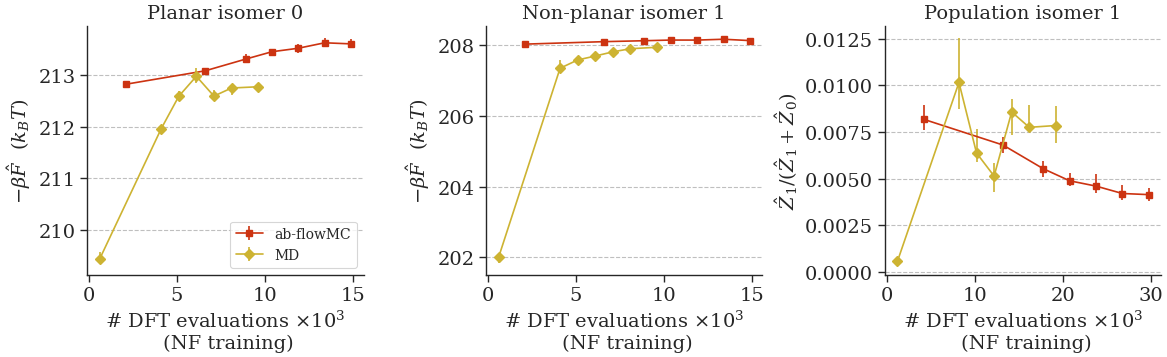

In [124]:
#BOXPLOT
# def plot_subplot(ax, title, data, positions, color_index, label):
#     ax.set_title(title)
#     box_plot = ax.boxplot(data, positions=positions,
#                           patch_artist=True,
#                           widths=1000,
#                           boxprops=dict(facecolor="C{:d}".format(color_index), color="C{:d}".format(color_index), alpha=0.5),
#                           whiskerprops=dict(color="C{:d}".format(color_index)),
#                           medianprops=dict(color='black'),
#                           flierprops=dict(marker='d', markersize=5, alpha=0.5, markeredgecolor="C{:d}".format(color_index), markerfacecolor="C{:d}".format(color_index))
#                           )
#     ax.plot(positions, np.median(data, axis=1), color="C{:d}".format(color_index), linewidth=1, linestyle='--')
#     ax.set_xlabel('$\#$ DFT evaluations during training')
#     ax.set_axisbelow(True)
#     ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
#     ax.set_ylabel(r'$k_B T$')
#     ax.set_xticks(np.linspace(0, 20400, num=6))
#     ax.set_xticklabels(np.linspace(0, 20400, num=6))
#     ax.xaxis.set_major_formatter(StrMethodFormatter('{x: .0f}'))




# figsize=(5.5*3, 1.5*3)
figsize=(4*3, 1.3*3)
fontsize=14
size_axes_label=14
size_tick_label=14
size_legend=10
linewidth=2
markersize=5
hspace=0.2
wspace=0.4

sns.set_context("paper", rc={"font.size":fontsize,
                        "axes.titlesize":fontsize,
                        "axes.labelsize":size_axes_label,
                        "xtick.labelsize":size_tick_label,
                        "ytick.labelsize":size_tick_label,
                        "legend.fontsize":size_tick_label,
                        })   


def plot_subplot(ax, title, data, positions, color, marker='d', ylabel=r'$k_B T$', ls='-', label=None):
    ax.set_title(title)
    
    # Using plt.errorbar instead of boxplot
    # Calculate median and interquartile range (IQR)
    medians = np.median(data, axis=1)
    q1 = np.percentile(data, 5, axis=1)
    q3 = np.percentile(data, 95, axis=1)
    
    # Calculate errors for errorbar
    errors = [medians - q1, q3 - medians]
    
    # Plot errorbar
    ax.errorbar(positions/10**3, medians, yerr=errors, fmt=marker,
                color=color, markerfacecolor=None, label=label, linestyle=ls)
    
    ax.set_xlabel(r'$\#$ DFT evaluations $\times 10^{3}$'+'\n (NF training)')
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    ax.set_ylabel(ylabel)


mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2024-03-15-abmc-flows-BAR-results'
df = pd.read_csv(filename + '.csv')
md_training_size = 500
random_point_mlp_training_sizes = [500] # , 1500]
sample_size = 200000
flow_train_slices = np.linspace(0, 50, 11, dtype=int)[:7]
# flow_train_slices = np.array([0, 3, 6, 9, 12, 15]) #, 18]) #, 21, 24, 27, 30])

plt.figure(figsize=figsize)
axs = [plt.subplot(1, 3, i + 1) for i in range(3)]
# plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - Comparing MD trainingsize - MLP train slice {:d}'.format(sample_size, mlp_train_slice))

handles = []

lss = ['-', '-']

# AbFlowMM results - flow training slice -1
for m, random_point_mlp_training_size in enumerate(random_point_mlp_training_sizes):
    label='ab-flowMC (init: {:d} random points for MLP pretraining)'.format(random_point_mlp_training_size)
    z0s, z1s, zrs = [], [], []

    if m == 1:
        flow_train_slices = flow_train_slices[:-1]

    for flow_train_slice in flow_train_slices:

        # labels = ['{:d}'.format(flow_train_slice)]
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['random_point_mlp_training_size'] == random_point_mlp_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0, z_1 = (-log_r_0), (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)
    
    positions_mcmc = []
    for f in flow_train_slices:
        if f < 5:
            budget = (f + 1) * 20 * 50
        elif f < 10:
            budget = (5 + (f + 1 - 5) * 0.5) * 20 * 50
        else:
            budget = (5 + 5 * 0.5 + (f + 1 - 10) * 0.3) * 20 * 50

        positions_mcmc.append(budget)

    positions = np.array(positions_mcmc) + random_point_mlp_training_size + md_training_size + 100
    for i, (z_data, subplot_title) in enumerate(zip([z0s, z1s, zrs], ['- $\\beta$ isomer 0', '- $\\beta$ FE isomer 1', 'Isomer 1 population'])):
        
        if i == 2:
            positions = 2 * positions #needs twice the number of evaluations to compute the free energy difference

        # label_two_lines = ' \n('.join(label.split(' ('))
        # print(label_two_lines)
        label_shortened = label.split(' ')[0]
        plot_subplot(axs[i], subplot_title, z_data, positions, model_colors[label], marker=model_markers[label],
                    #  label=label_two_lines,
                    label=label_shortened,
                    ls=lss[m])

    # handles.append(mpatches.Patch(color="C{:d}".format(m + 2), alpha=0.5, label=label))

########### ADDING MD results
mlp_train_slice = 30

filename = subproject_path + '9-mcmc-bar/2024-02-26-MD-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv')
md_training_sizes = [500, 4000, 5000, 6000, 7000, 8000, 9500]
sample_size = 200000
flow_train_slices = [0]

z0s, z1s, zrs = [], [], []

for md_training_size in md_training_sizes:
    for flow_train_slice in flow_train_slices:
        # labels.append('{:d}'.format(md_training_size))
        df_abflow = df.loc[df['kind'] == 'MD']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]
        df_abflow = df_abflow.loc[df_abflow['mlp_train_slice'] == mlp_train_slice]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0, z_1 = (-log_r_0), (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)
label = 'MD'
positions = np.array(md_training_sizes) + 100
for i, (z_data, subplot_title) in enumerate(zip([z0s, z1s, zrs], ['Planar isomer 0' ,
                                                                #   \n Absolute Free Energy', 
                                                                  'Non-planar isomer 1',
                                                                    # \n Absolute Free Energy', 
                                                                    'Population isomer 1'])):
    print(i, subplot_title)

    ylabel = r"$-\beta \hat F$  ($k_B T$)"
    if i == 2:
        positions = 2 * positions #needs twice the number of evaluations to compute the free energy difference
        ylabel = r'$\hat Z_1 / (\hat Z_1 + \hat Z_0)$'

    plot_subplot(axs[i], subplot_title, z_data, positions, model_colors['MD'], label=label, ylabel=ylabel, marker=model_markers['MD'])

# handles.append(mpatches.Patch(color="C0", alpha=0.5, label='MD'))

# Adding legend
# plt.legend(handles=handles)
for ax in axs: 
    ax.spines[['right', 'top']].set_visible(False)
# for a in range(2):
#     plt.setp(axs[a].get_xticklabels(), visible=False)

plt.sca(axs[0])
plt.legend(fontsize=size_legend)
plt.tight_layout()
plt.savefig('paper_figures/absolute_free_energies_randompoints_2503.png')


# 7 - Test likelihood, free energies and overfitting

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import lines
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.legend_handler import HandlerLine2D
import matplotlib.path as mpath
from matplotlib.transforms import BboxTransformFrom, BboxTransformTo, Bbox
import string


class HandlerMiniatureLine(HandlerLine2D):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize,
                       trans):

        legline, _ = HandlerLine2D.create_artists(self,legend, orig_handle,
                                xdescent, ydescent, width, height, fontsize, trans)

        legline.set_data(*orig_handle.get_data())

        ext = mpath.get_paths_extents([orig_handle.get_path()])
        if ext.width == 0:
            ext.x0 -= 0.1
            ext.x1 += 0.1
        bbox0 = BboxTransformFrom(ext)
        bbox1 = BboxTransformTo(Bbox.from_bounds(xdescent, ydescent, width, height))

        legline.set_transform(bbox0 + bbox1 + trans)
        return legline,

/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_2728/2439128623.py:84: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  axs[3] = plt.subplot2grid((2, 3), (1, 0), sharex=axs[0])
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_2728/2439128623.py:85: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  axs[4] = plt.subplot2grid((2, 3), (1, 1), sharex=axs[1])
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_2728/2439128623.py:86: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  axs[2] = plt.subplot2grid((2, 3), (0, 2), colspan=1, rowspan=2)


KeyError: '${N_{\\rm flow}$: $10000 - $N_{\\rm MD}$: 500'

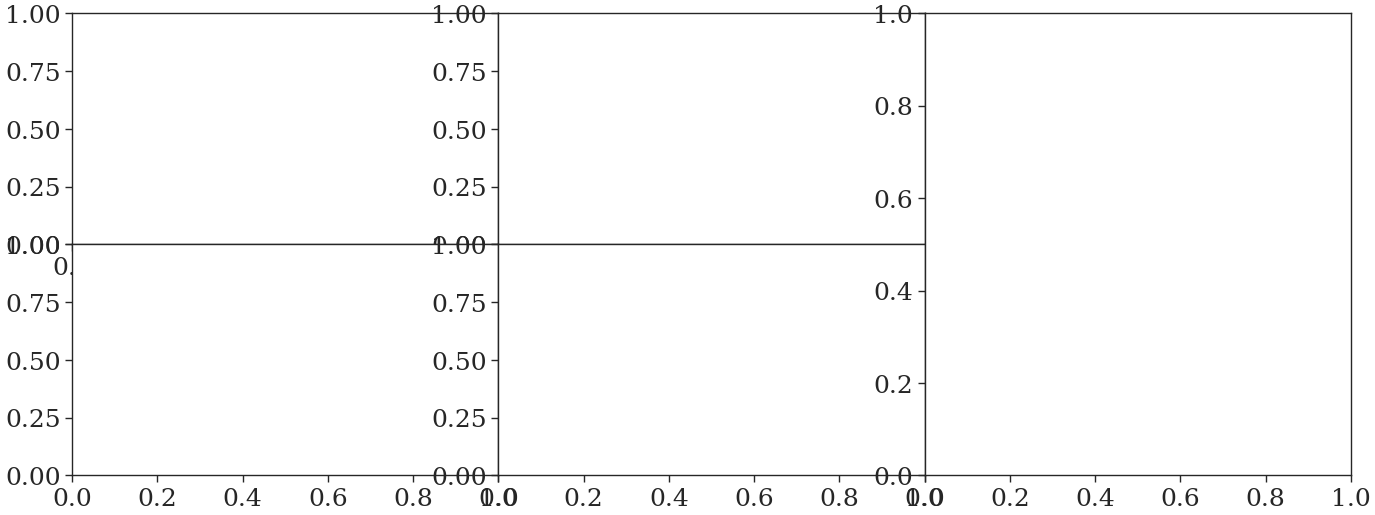

In [38]:

#BOXPLOT
# def plot_subplot(ax, title, data, positions, color_index, label):
#     ax.set_title(title)
#     box_plot = ax.boxplot(data, positions=positions,
#                           patch_artist=True,
#                           widths=1000,
#                           boxprops=dict(facecolor="C{:d}".format(color_index), color="C{:d}".format(color_index), alpha=0.5),
#                           whiskerprops=dict(color="C{:d}".format(color_index)),
#                           medianprops=dict(color='black'),
#                           flierprops=dict(marker='d', markersize=5, alpha=0.5, markeredgecolor="C{:d}".format(color_index), markerfacecolor="C{:d}".format(color_index))
#                           )
#     ax.plot(positions, np.median(data, axis=1), color="C{:d}".format(color_index), linewidth=1, linestyle='--')
#     ax.set_xlabel('$\#$ DFT evaluations during training')
#     ax.set_axisbelow(True)
#     ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
#     ax.set_ylabel(r'$k_B T$')
#     ax.set_xticks(np.linspace(0, 20400, num=6))
#     ax.set_xticklabels(np.linspace(0, 20400, num=6))
#     ax.xaxis.set_major_formatter(StrMethodFormatter('{x: .0f}'))



figsize=(5.5*3, 2*3)
fontsize=18
size_axes_label=18
size_tick_label=18
size_legend=14
linewidth=2
markersize=5
hspace=0
wspace=0

sns.set_context("paper", rc={"font.size":fontsize,
                        "axes.titlesize":fontsize,
                        "axes.labelsize":size_axes_label,
                        "xtick.labelsize":size_tick_label,
                        "ytick.labelsize":size_tick_label,
                        "legend.fontsize":size_tick_label,
                        })   


def plot_subplot(ax, title, data, positions, color, marker='d', ylabel=r'$k_B T$', ls='-',
                 label=None,drawxlabel=True):
    ax.set_title(title)
    
    # Using plt.errorbar instead of boxplot
    # Calculate median and interquartile range (IQR)
    medians = np.median(data, axis=1)
    q1 = np.percentile(data, 5, axis=1)
    q3 = np.percentile(data, 95, axis=1)
    
    # Calculate errors for errorbar
    errors = [medians - q1, q3 - medians]
    
    # Plot errorbar
    ax.errorbar(positions/10**3, medians, yerr=errors, fmt=marker, color=color, 
                label=label, linestyle=ls, markersize=7)
    
    if drawxlabel:
        ax.set_xlabel(r'$\#$ DFT evaluations $\times 10^{3}$'+'\n (NF training)')
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    ax.set_ylabel(ylabel)


mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2024-03-15-abmc-flows-BAR-results'
df = pd.read_csv(filename + '.csv')
sample_size = 200000

filename = subproject_path + '9-mcmc-bar/2024-03-15-test-losses-abmc-flows'
df_test = pd.read_csv(filename + '.csv') 
sample_size_test = 18000

md_training_size = 500

flow_train_slices = np.linspace(0, 50, 11, dtype=int)
# flow_train_slices = np.array([0, 3, 6, 9, 12, 15]) #, 18]) #, 21, 24, 27, 30])

fig = plt.figure(figsize=figsize)
fig.subplots_adjust(hspace=hspace, wspace=wspace)
# subplot2grid with 3 columns and 2 rows (3x2 grid)
axs = [plt.subplot(2, 3, i + 1) for i in range(5)]
axs[3] = plt.subplot2grid((2, 3), (1, 0), sharex=axs[0])
axs[4] = plt.subplot2grid((2, 3), (1, 1), sharex=axs[1])
axs[2] = plt.subplot2grid((2, 3), (0, 2), colspan=1, rowspan=2)


# axs = [plt.subplot(2, 3, i + 1) for i in range(6)]
# plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - Comparing MD trainingsize - MLP train slice {:d}'.format(sample_size, mlp_train_slice))

handles = []

lss = ['-', '-']

# AbFlowMM results - flow training slice -1
for m, random_point_mlp_training_size in enumerate(random_point_mlp_training_sizes):
    label='ab-flowMC (init: {:d} random points for MLP pretraining)'.format(random_point_mlp_training_size)
    z0s, z1s, zrs = [], [], []
    test_loss_0s, test_loss_1s = [], []

    if m == 1:
        flow_train_slices = flow_train_slices[:-1]

    for flow_train_slice in flow_train_slices:

        # labels = ['{:d}'.format(flow_train_slice)]
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['random_point_mlp_training_size'] == random_point_mlp_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0, z_1 = (-log_r_0), (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)

        df_abflow = df_test.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['random_points_mlp_training'] == random_point_mlp_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size_test]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        test_loss_0 = df_abflow_0['test_losses'].values
        test_loss_1 = df_abflow_1['test_losses'].values

        test_loss_0s.append(test_loss_0)
        test_loss_1s.append(test_loss_1)

    
    positions = (flow_train_slices + 1) * 20 * 50 + md_training_size + random_point_mlp_training_size + 100
    for i, (z_data, subplot_title) in enumerate(zip([zrs, z0s, z1s], ['Population isomer 1',None, None])):
        drawxlabel=True
        if i == 0:
            new_positions = 2 * positions #needs twice the number of evaluations to compute the free energy difference
            ylabel = r'$\hat Z_1 / (\hat Z_1 + \hat Z_0)$'
        else:
            ylabel = r"$-\beta \hat F$  ($k_B T$)"
            new_positions = positions
        label_two_lines = ' \n ('.join(label.split(' ('))
        plot_subplot(axs[i + 2], subplot_title, z_data, new_positions, model_colors[label], 
                     marker=model_markers[label],
                     label=label_two_lines, ls=lss[m], ylabel=ylabel, drawxlabel=drawxlabel)

    ylabel = r'NLL$_{\mathrm{test}}$'
    positions = (flow_train_slices + 1) * 20 * 50 + md_training_size + 100
    for i, (z_data, subplot_title) in enumerate(zip([test_loss_0s, test_loss_1s], ['Planar isomer 0' ,
                                                                #   \n Absolute Free Energy', 
                                                                  'Non-planar isomer 1']
                                                                    # \n Absolute Free Energy', 
                                                                    # 'Population isomer 1']
                                                                    )):
        drawxlabel=False
        label_two_lines = ' \n ('.join(label.split(' ('))
        plot_subplot(axs[i], subplot_title, z_data, positions, model_colors[label], 
                     marker=model_markers[label], label=label_two_lines, ls=lss[m], ylabel=ylabel, drawxlabel=drawxlabel)

    # handles.append(mpatches.Patch(color="C{:d}".format(m + 2), alpha=0.5, label=label))

########### ADDING MD results
# mlp_train_slice = 30

# filename = subproject_path + '9-mcmc-bar/2023-12-22-md-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
# df = pd.read_csv(filename + '.csv')
# md_training_sizes = [500, 4000, 5000, 6000, 7000, 8000, 9500]
# sample_size = 200000
# flow_train_slices = [0]

# z0s, z1s, zrs = [], [], []

# for md_training_size in md_training_sizes:
#     for flow_train_slice in flow_train_slices:
#         # labels.append('{:d}'.format(md_training_size))
#         df_abflow = df.loc[df['kind'] == 'MD']
#         df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
#         df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
#         df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]
#         df_abflow = df_abflow.loc[df_abflow['mlp_train_slice'] == mlp_train_slice]

#         df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
#         df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

#         log_r_0 = df_abflow_0['log_r'].values
#         log_r_1 = df_abflow_1['log_r'].values

#         z_r = np.exp(log_r_0 - log_r_1)
#         zrs.append(z_r)

#         z_0, z_1 = (-log_r_0), (-log_r_1)
#         z0s.append(z_0)
#         z1s.append(z_1)
# label = 'MD'
# positions = np.array(md_training_sizes) + 100
# for i, (z_data, subplot_title) in enumerate(zip([z0s, z1s, zrs], ['Isomer 0 \n Absolute Free Energy', 'Isomer 1 \n Absolute Free Energy', 'Population Isomer 1'])):
#     print(i, subplot_title)

#     ylabel = r"$-\beta \hat F$  ($k_B T$)"
#     if i == 2:
#         positions = 2 * positions #needs twice the number of evaluations to compute the free energy difference
#         ylabel = r'$\hat Z_1 / (\hat Z_1 + \hat Z_0)$'

#     plot_subplot(axs[i], subplot_title, z_data, positions, model_colors['MD'], label=label, ylabel=ylabel)

# handles.append(mpatches.Patch(color="C0", alpha=0.5, label='MD'))

# Adding legend
# plt.legend(handles=handles)
        
posx = -0.05
posy = 1.05
order_letters = ['A', 'B', 'E', 'C', 'D']
for a,ax in zip(order_letters, axs): 
    ax.spines[['right', 'top']].set_visible(False)
    ax.text(posx+0.025,
            posy-0.025, 
            a, 
            transform=ax.transAxes, 
            weight='bold',)
# for a in range(2):
#     plt.setp(axs[a].get_xticklabels(), visible=False)
    

# vertical lines in legend
def update_prop(handle, orig):
    handle.update_from(orig)
    x,y = handle.get_data()
    handle.set_data([np.mean(x)]*2, [0, 2*y[0]])

# axs[4].axvline(x=23, lw=3, ls=":", c=model_colors['ab-flowMC (init: 1500 random points for MLP pretraining)'])
# axs[1].axvline(x=23, lw=3, ls=":", c=model_colors['ab-flowMC (init: 1500 random points for MLP pretraining)'], label='overfitting \n onset')
# axs[2].axvline(x=2 * 23, lw=3, ls=":", c=model_colors['ab-flowMC (init: 1500 random points for MLP pretraining)'], label='overfitting \n onset')

# axs[3].axvline(x=16.5, lw=3, ls=":", c=model_colors['ab-flowMC (init: 500 random points for MLP pretraining)'])
# axs[0].axvline(x=16.5, lw=3, ls=":", c=model_colors['ab-flowMC (init: 500 random points for MLP pretraining)'], label='overfitting \n onset')
# axs[2].axvline(x=2 * 16.5, lw=3, ls=":", c=model_colors['ab-flowMC (init: 500 random points for MLP pretraining)'], label='overfitting \n onset')


# #only keep the last line of axs[3] in legend
# handles, labels = axs[0].get_legend_handles_labels()
# print(handles)
# handles = [handles[0]]
# labels = [labels[0]]
# axs[0].legend(handles, labels, fontsize=size_legend, handlelength=3)#, handler_map={plt.Line2D:HandlerLine2D(update_func=update_prop)})

# #only keep the last line of axs[3] in legend
# handles, labels = axs[1].get_legend_handles_labels()
# print(handles)
# handles = [handles[0]]
# labels = [labels[0]]
# axs[1].legend(handles, labels, fontsize=size_legend, handlelength=3) #, handler_map={plt.Line2D:HandlerLine2D(update_func=update_prop)})


plt.sca(axs[2])
handles, labels = axs[2].get_legend_handles_labels()
handles, labels = handles[-2:], labels[-2:]
axs[2].legend(handles, labels, fontsize=size_legend, loc='upper left')
# plt.legend(fontsize=size_legend)


plt.tight_layout()
plt.savefig('paper_figures/free_energies_and_overfitting_wvline_aciinumbers_randompoints.png')


# 8 - Putting all the results to the same plot to illustrate overfitting and stability of the free energy estimation

In [9]:
# set sns theme with science format
sns.set_theme(style='ticks', rc=science)

model_colors = dict(zip([
                         'Nf500Nm500',
                         'Nf10000Nm500',
                         'Nf10000Nm4000'
                         ],
                        ['#CC3311', 'black', 'gray'])) # '#ca247c']))
model_markers = dict(zip(['Nf500Nm500',
                         'Nf10000Nm500',
                         'Nf10000Nm4000'],
                        ['o', 's', 'D', '^'])) # 'v']))

overfit_indices = dict(zip(['Nf500Nm500-0',
                          'Nf500Nm500-1',
                         'Nf10000Nm500-0',
                         'Nf10000Nm500-1',
                         'Nf10000Nm4000-0',
                         'Nf10000Nm4000-1'],
                        [7, 100, 6, 100, 100, 6])) # 'v']))

sns.color_palette(model_colors.values())

model_colors

{'Nf500Nm500': '#CC3311', 'Nf10000Nm500': 'black', 'Nf10000Nm4000': 'gray'}

/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_49232/3712617035.py:80: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  axs[3] = plt.subplot2grid((2, 3), (1, 0), sharex=axs[0])
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_49232/3712617035.py:81: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  axs[4] = plt.subplot2grid((2, 3), (1, 1), sharex=axs[1])
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_49232/3712617035.py:82: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  axs[2] = plt.subplot2grid((2, 3), (0, 2), colspan=1, rowspan=2)


[ 1000.  5500.  7800.  9300. 10800. 12300. 13800. 15300. 16800. 18300.
 19800.]
overfit 7
overfit 100
[ 300. 1200. 2100. 3000. 3900. 4800. 5700. 6600. 7500. 8400. 9300.]
overfit 6
overfit 100
overfit 100
overfit 6
[ 300. 1200. 2100. 3000. 3900. 4800. 5700. 6600. 7500. 8400. 9300.]
overfit 6
overfit 100
overfit 100
overfit 6


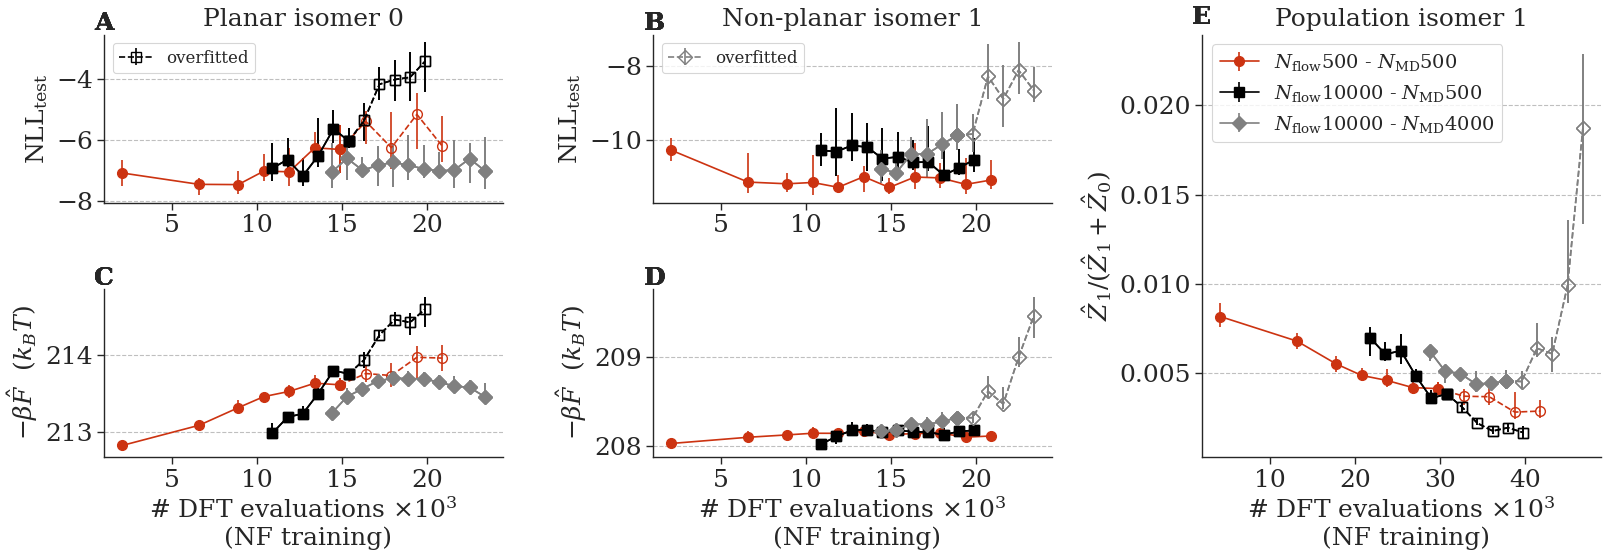

In [42]:

#BOXPLOT
# def plot_subplot(ax, title, data, positions, color_index, label):
#     ax.set_title(title)
#     box_plot = ax.boxplot(data, positions=positions,
#                           patch_artist=True,
#                           widths=1000,
#                           boxprops=dict(facecolor="C{:d}".format(color_index), color="C{:d}".format(color_index), alpha=0.5),
#                           whiskerprops=dict(color="C{:d}".format(color_index)),
#                           medianprops=dict(color='black'),
#                           flierprops=dict(marker='d', markersize=5, alpha=0.5, markeredgecolor="C{:d}".format(color_index), markerfacecolor="C{:d}".format(color_index))
#                           )
#     ax.plot(positions, np.median(data, axis=1), color="C{:d}".format(color_index), linewidth=1, linestyle='--')
#     ax.set_xlabel('$\#$ DFT evaluations during training')
#     ax.set_axisbelow(True)
#     ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
#     ax.set_ylabel(r'$k_B T$')
#     ax.set_xticks(np.linspace(0, 20400, num=6))
#     ax.set_xticklabels(np.linspace(0, 20400, num=6))
#     ax.xaxis.set_major_formatter(StrMethodFormatter('{x: .0f}'))



figsize=(5.5*3, 2*3)
fontsize=18
size_axes_label=18
size_tick_label=18
size_legend=14
linewidth=2
markersize=5
hspace=0
wspace=0

sns.set_context("paper", rc={"font.size":fontsize,
                        "axes.titlesize":fontsize,
                        "axes.labelsize":size_axes_label,
                        "xtick.labelsize":size_tick_label,
                        "ytick.labelsize":size_tick_label,
                        "legend.fontsize":size_tick_label,
                        })   


def plot_subplot(ax, title, data, positions, color, marker='d', ylabel=r'$k_B T$', ls='-',
                 label=None,drawxlabel=True, overfit_index=None):
    ax.set_title(title)
    
    # Using plt.errorbar instead of boxplot
    # Calculate median and interquartile range (IQR)
    medians = np.median(data, axis=1)
    q1 = np.percentile(data, 5, axis=1)
    q3 = np.percentile(data, 95, axis=1)
    
    # Calculate errors for errorbar
    errors = [medians - q1, q3 - medians]


    if overfit_index is not None:
        ax.errorbar(positions[:overfit_index]/10**3, medians[:overfit_index],
                    yerr=[errors[0][:overfit_index],errors[1][:overfit_index]], fmt=marker, color=color, 
                label=label, linestyle='-', markersize=7)
        
        ax.errorbar(positions[overfit_index-1:]/10**3, medians[overfit_index-1:], 
                    yerr=[errors[0][overfit_index-1:],errors[1][overfit_index-1:]], fmt=marker, color=color,
                label=label, linestyle='--', markersize=7, markerfacecolor='none')
    else:
        # Plot errorbar
        ax.errorbar(positions/10**3, medians, yerr=errors, fmt=marker, color=color, 
                    label=label, linestyle=ls, markersize=7)
    
    if drawxlabel:
        ax.set_xlabel(r'$\#$ DFT evaluations $\times 10^{3}$'+'\n (NF training)')
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    ax.set_ylabel(ylabel)


fig = plt.figure(figsize=figsize)
fig.subplots_adjust(hspace=hspace, wspace=wspace)
# subplot2grid with 3 columns and 2 rows (3x2 grid)
axs = [plt.subplot(2, 3, i + 1) for i in range(5)]
axs[3] = plt.subplot2grid((2, 3), (1, 0), sharex=axs[0])
axs[4] = plt.subplot2grid((2, 3), (1, 1), sharex=axs[1])
axs[2] = plt.subplot2grid((2, 3), (0, 2), colspan=1, rowspan=2)

handles = []    


for iteration in range(3):
    if iteration == 0:
        ## NEWEST RESULTS:
        md_training_sizes = [500]
        random_point_mlp_training_sizes = [500] # , 1500]

        mlp_hyper_parameters = 'config1'
        filename = subproject_path + '9-mcmc-bar/2024-03-15-abmc-flows-BAR-results'
        df = pd.read_csv(filename + '.csv')
        sample_size = 200000

        filename = subproject_path + '9-mcmc-bar/2024-03-15-test-losses-abmc-flows'
        df_test = pd.read_csv(filename + '.csv') 
        sample_size_test = 18000

        flow_train_slices = np.linspace(0, 50, 11, dtype=int)
        
        positions_mcmc = []

        for f in flow_train_slices:
            if f < 5:
                budget = (f + 1) * 20 * 50
            elif f < 10:
                budget = (5 + (f + 1 - 5) * 0.5) * 20 * 50
            else:
                budget = (5 + 5 * 0.5 + (f + 1 - 10) * 0.3) * 20 * 50

            positions_mcmc.append(budget)

        positions_mcmc = np.array(positions_mcmc)
        print(positions_mcmc)

    # elif iteration == 1:
    #     mlp_train_slice = 30
    #     ## LATER RESULTS:
    #     random_point_mlp_training_sizes = [500, 1500]
    #     md_training_sizes = [500]
    #     mlp_hyper_parameters = 'config2'
    #     filename = subproject_path + '9-mcmc-bar/2024-02-26-abmc-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
    #     df = pd.read_csv(filename + '.csv')
    #     sample_size = 200000

    #     filename = subproject_path + '9-mcmc-bar/2024-02-26-test-losses-abmc-flows-mlpmodel{:d}'.format(mlp_train_slice)
    #     df_test = pd.read_csv(filename + '.csv') 
    #     sample_size_test = 18000

    #     flow_train_slices = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30])
    #     positions_mcmc = (flow_train_slices + 1) * 20 * 50 * 0.3 
    #     print(positions_mcmc)

    else:
        ## ORIGINAL RESULTS:
        mlp_train_slice = 30
        random_point_mlp_training_sizes = [10000]
        md_training_sizes = [500, 4000]

        filename = subproject_path + '9-mcmc-bar/2023-12-05-abmc-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
        df = pd.read_csv(filename + '.csv')
        sample_size = 200000

        filename = subproject_path + '9-mcmc-bar/2023-12-22-test-losses-abmc-flows-mlpmodel{:d}'.format(mlp_train_slice)
        df_test = pd.read_csv(filename + '.csv') 
        sample_size_test = 18000

        flow_train_slices = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30])
        positions_mcmc = (flow_train_slices + 1) * 20 * 50 * 0.3 
        print(positions_mcmc)

    lss = ['-', '-']

    # AbFlowMM results - flow training slice -1
    for md_training_size in md_training_sizes:
        for m, random_point_mlp_training_size in enumerate(random_point_mlp_training_sizes):
            positions = positions_mcmc + md_training_size + random_point_mlp_training_size + 100    

            
            label=r'$N_{\rm flow} $' + '{:d} - '.format(random_point_mlp_training_size) +r'$N_{\rm MD} $'+ '{:d}'.format( md_training_size)
            # label_key='ab-flowMC (init: {:d} random points for MLP pretraining)'.format(random_point_mlp_training_size)
            label_key = 'Nf{:d}Nm{:d}'.format(random_point_mlp_training_size, md_training_size)

            z0s, z1s, zrs = [], [], []
            test_loss_0s, test_loss_1s = [], []

            if m == 1 and iteration == 0:
                flow_train_slices = flow_train_slices[:-1]

            for flow_train_slice in flow_train_slices:

                # labels = ['{:d}'.format(flow_train_slice)]
                df_abflow = df.loc[df['kind'] == 'ab-flowMC']
                df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
                if iteration == 0:
                    df_abflow = df_abflow.loc[df_abflow['random_point_mlp_training_size'] == random_point_mlp_training_size]
                df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
                df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

                df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
                df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

                log_r_0 = df_abflow_0['log_r'].values
                log_r_1 = df_abflow_1['log_r'].values

                z_r = np.exp(log_r_0 - log_r_1)
                zrs.append(z_r)

                z_0, z_1 = (-log_r_0), (-log_r_1)
                z0s.append(z_0)
                z1s.append(z_1)

                df_abflow = df_test.loc[df['kind'] == 'ab-flowMC']
                df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
                if iteration == 0:
                    df_abflow = df_abflow.loc[df_abflow['random_points_mlp_training'] == random_point_mlp_training_size]
                df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
                df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size_test]

                df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
                df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

                test_loss_0 = df_abflow_0['test_losses'].values
                test_loss_1 = df_abflow_1['test_losses'].values

                test_loss_0s.append(test_loss_0)
                test_loss_1s.append(test_loss_1)

            
            for i, (z_data, subplot_title) in enumerate(zip([zrs, z0s, z1s], ['Population isomer 1', None, None])):
                drawxlabel=True
                if i == 0:
                    new_positions = 2 * positions #needs twice the number of evaluations to compute the free energy difference
                    ylabel = r'$\hat Z_1 / (\hat Z_1 + \hat Z_0)$'
                    overfit_index = min(overfit_indices[label_key + '-0'], overfit_indices[label_key + '-1'])
                else:
                    ylabel = r"$-\beta \hat F$  ($k_B T$)"
                    new_positions = positions
                    overfit_index = overfit_indices[label_key + '-{:d}'.format(i-1)]
                    print('overfit', overfit_index)

                label_two_lines = ' \n ('.join(label.split(' ('))
                
                plot_subplot(axs[i + 2], subplot_title, z_data, new_positions, model_colors[label_key], 
                            marker=model_markers[label_key],
                            label=label_two_lines, 
                            ls=lss[m], 
                            ylabel=ylabel, 
                            drawxlabel=drawxlabel, 
                            overfit_index=overfit_index)

            ylabel = r'NLL$_{\mathrm{test}}$'
            # positions = (flow_train_slices + 1) * 20 * 50 + md_training_size + 100
            for i, (z_data, subplot_title) in enumerate(zip([test_loss_0s, test_loss_1s], ['Planar isomer 0' ,
                                                                        #   \n Absolute Free Energy', 
                                                                        'Non-planar isomer 1']
                                                                            # \n Absolute Free Energy', 
                                                                            # 'Population isomer 1']
                                                                            )):
                drawxlabel=False
                label_two_lines = ' \n ('.join(label.split(' ('))
                plot_subplot(axs[i], subplot_title, z_data, positions, model_colors[label_key], 
                            marker=model_markers[label_key], label=label_two_lines, ls=lss[m],
                            ylabel=ylabel, drawxlabel=drawxlabel,
                            overfit_index=overfit_indices[label_key + '-{:d}'.format(i)])

            # handles.append(mpatches.Patch(color="C{:d}".format(m + 2), alpha=0.5, label=label))

            ########### ADDING MD results
            # mlp_train_slice = 30

            # filename = subproject_path + '9-mcmc-bar/2023-12-22-md-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
            # df = pd.read_csv(filename + '.csv')
            # md_training_sizes = [500, 4000, 5000, 6000, 7000, 8000, 9500]
            # sample_size = 200000
            # flow_train_slices = [0]

            # z0s, z1s, zrs = [], [], []

            # for md_training_size in md_training_sizes:
            #     for flow_train_slice in flow_train_slices:
            #         # labels.append('{:d}'.format(md_training_size))
            #         df_abflow = df.loc[df['kind'] == 'MD']
            #         df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
            #         df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
            #         df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]
            #         df_abflow = df_abflow.loc[df_abflow['mlp_train_slice'] == mlp_train_slice]

            #         df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
            #         df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

            #         log_r_0 = df_abflow_0['log_r'].values
            #         log_r_1 = df_abflow_1['log_r'].values

            #         z_r = np.exp(log_r_0 - log_r_1)
            #         zrs.append(z_r)

            #         z_0, z_1 = (-log_r_0), (-log_r_1)
            #         z0s.append(z_0)
            #         z1s.append(z_1)
            # label = 'MD'
            # positions = np.array(md_training_sizes) + 100
            # for i, (z_data, subplot_title) in enumerate(zip([z0s, z1s, zrs], ['Isomer 0 \n Absolute Free Energy', 'Isomer 1 \n Absolute Free Energy', 'Population Isomer 1'])):
            #     print(i, subplot_title)

            #     ylabel = r"$-\beta \hat F$  ($k_B T$)"
            #     if i == 2:
            #         positions = 2 * positions #needs twice the number of evaluations to compute the free energy difference
            #         ylabel = r'$\hat Z_1 / (\hat Z_1 + \hat Z_0)$'

            #     plot_subplot(axs[i], subplot_title, z_data, positions, model_colors['MD'], label=label, ylabel=ylabel)

            # handles.append(mpatches.Patch(color="C0", alpha=0.5, label='MD'))

            # Adding legend
            # plt.legend(handles=handles)
                    
            posx = -0.05
            posy = 1.05
            order_letters = ['A', 'B', 'E', 'C', 'D']
            for a,ax in zip(order_letters, axs): 
                ax.spines[['right', 'top']].set_visible(False)
                ax.text(posx+0.025,
                        posy-0.025, 
                        a, 
                        transform=ax.transAxes, 
                        weight='bold',)
            # for a in range(2):
            #     plt.setp(axs[a].get_xticklabels(), visible=False)
                

            # vertical lines in legend
            def update_prop(handle, orig):
                handle.update_from(orig)
                x,y = handle.get_data()
                handle.set_data([np.mean(x)]*2, [0, 2*y[0]])

            # axs[4].axvline(x=23, lw=3, ls=":", c=model_colors['ab-flowMC (init: 1500 random points for MLP pretraining)'])
            # axs[1].axvline(x=23, lw=3, ls=":", c=model_colors['ab-flowMC (init: 1500 random points for MLP pretraining)'], label='overfitting \n onset')
            # axs[2].axvline(x=2 * 23, lw=3, ls=":", c=model_colors['ab-flowMC (init: 1500 random points for MLP pretraining)'], label='overfitting \n onset')

            # axs[3].axvline(x=16.5, lw=3, ls=":", c=model_colors['ab-flowMC (init: 500 random points for MLP pretraining)'])
            # axs[0].axvline(x=16.5, lw=3, ls=":", c=model_colors['ab-flowMC (init: 500 random points for MLP pretraining)'], label='overfitting \n onset')
            # axs[2].axvline(x=2 * 16.5, lw=3, ls=":", c=model_colors['ab-flowMC (init: 500 random points for MLP pretraining)'], label='overfitting \n onset')


            # #only keep the last line of axs[3] in legend
            # handles, labels = axs[0].get_legend_handles_labels()
            # print(handles)
            # handles = [handles[0]]
            # labels = [labels[0]]
            # axs[0].legend(handles, labels, fontsize=size_legend, handlelength=3)#, handler_map={plt.Line2D:HandlerLine2D(update_func=update_prop)})

            # #only keep the last line of axs[3] in legend
            # handles, labels = axs[1].get_legend_handles_labels()
            # print(handles)
            # handles = [handles[0]]
            # labels = [labels[0]]
            # axs[1].legend(handles, labels, fontsize=size_legend, handlelength=3) #, handler_map={plt.Line2D:HandlerLine2D(update_func=update_prop)})


plt.sca(axs[2])
handles, labels = axs[2].get_legend_handles_labels()
handles = [handles[i] for i in [0, 2, 4]]
labels = [labels[i] for i in [0, 2, 4]]
axs[2].legend(handles, labels, fontsize=size_legend, loc='upper left')
# plt.legend(fontsize=size_legend)

handles, labels = axs[0].get_legend_handles_labels()
axs[0].legend(handles[3:4], ['overfitted'], fontsize=12)


handles, labels = axs[1].get_legend_handles_labels()
axs[1].legend(handles[5:6], ['overfitted'], fontsize=12)

plt.tight_layout()
plt.savefig('paper_figures/free_energies_and_overfitting_wvline_aciinumbers_randompoints_2503.png')
# plt.savefig('paper_figures/free_energies_and_overfitting_wvline_aciinumbers_randompoints_2503.pdf')


In [27]:
df

,kind,isomer_id,md_training_size,process_id_flow,flow_train_slice,mlp_train_slice,mc seed,log_r,trial,sample_size
0,ab-flowMC,0,4000,30019623,0,30,0,-213.240189,0,200000
1,ab-flowMC,0,4000,30019623,0,30,0,-213.321723,1,200000
2,ab-flowMC,0,4000,30019623,0,30,0,-213.263599,2,200000
3,ab-flowMC,0,4000,30019623,0,30,0,-213.229261,3,200000
4,ab-flowMC,0,4000,30019623,0,30,0,-213.360326,4,200000
...,...,...,...,...,...,...,...,...,...,...
435,ab-flowMC,1,500,30019624,30,30,0,-208.218332,5,200000
436,ab-flowMC,1,500,30019624,30,30,0,-208.193053,6,200000
437,ab-flowMC,1,500,30019624,30,30,0,-208.173869,7,200000
438,ab-flowMC,1,500,30019624,30,30,0,-208.160871,8,200000


In [10]:
model_colors = dict(zip([
                         'Nf500Nm500',
                         'Nf10000Nm500',
                         'Nf10000Nm4000',
                         'MD'
                         ],
                        ['#CC3311', 'black', 'gray','#cdb332' ])) # '#ca247c']))
model_markers = dict(zip(['Nf500Nm500',
                         'Nf10000Nm500',
                         'Nf10000Nm4000',
                         'MD'],
                        ['o', 's', 'D', '^', '*'])) # 'v']))

7 [ 2100.  6600.  8900. 10400. 11900. 13400. 14900.]
7 [ 2100.  6600.  8900. 10400. 11900. 13400. 14900.]
7 [ 4200. 13200. 17800. 20800. 23800. 26800. 29800.]
[ 300. 1200. 2100. 3000. 3900. 4800.]
6 [10900. 11800. 12700. 13600. 14500. 15400.]
6 [10900. 11800. 12700. 13600. 14500. 15400.]
6 [21800. 23600. 25400. 27200. 29000. 30800.]
6 [14400. 15300. 16200. 17100. 18000. 18900.]
6 [14400. 15300. 16200. 17100. 18000. 18900.]
6 [28800. 30600. 32400. 34200. 36000. 37800.]
0 Planar isomer 0
1 Non-planar isomer 1
2 Population isomer 1


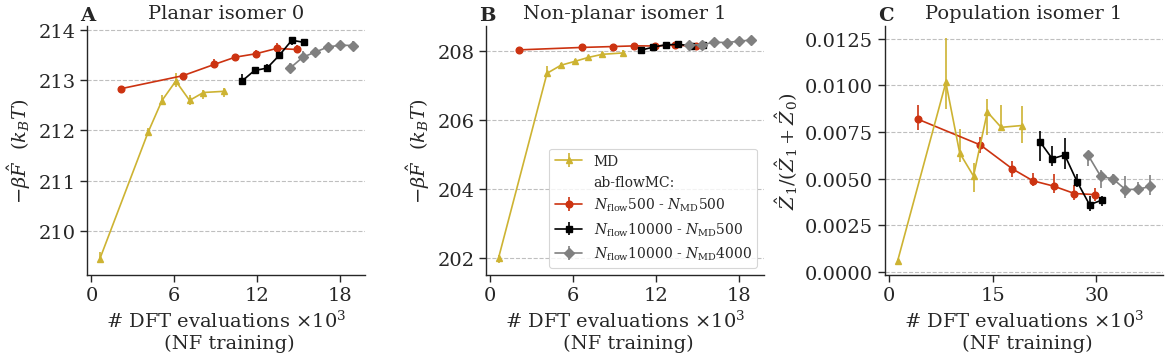

In [12]:
#BOXPLOT
# def plot_subplot(ax, title, data, positions, color_index, label):
#     ax.set_title(title)
#     box_plot = ax.boxplot(data, positions=positions,
#                           patch_artist=True,
#                           widths=1000,
#                           boxprops=dict(facecolor="C{:d}".format(color_index), color="C{:d}".format(color_index), alpha=0.5),
#                           whiskerprops=dict(color="C{:d}".format(color_index)),
#                           medianprops=dict(color='black'),
#                           flierprops=dict(marker='d', markersize=5, alpha=0.5, markeredgecolor="C{:d}".format(color_index), markerfacecolor="C{:d}".format(color_index))
#                           )
#     ax.plot(positions, np.median(data, axis=1), color="C{:d}".format(color_index), linewidth=1, linestyle='--')
#     ax.set_xlabel('$\#$ DFT evaluations during training')
#     ax.set_axisbelow(True)
#     ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
#     ax.set_ylabel(r'$k_B T$')
#     ax.set_xticks(np.linspace(0, 20400, num=6))
#     ax.set_xticklabels(np.linspace(0, 20400, num=6))
#     ax.xaxis.set_major_formatter(StrMethodFormatter('{x: .0f}'))




# figsize=(5.5*3, 1.5*3)
figsize=(4*3, 1.3*3)
fontsize=14
size_axes_label=14
size_tick_label=14
size_legend=10
linewidth=2
markersize=5
hspace=0.2
wspace=0.4

sns.set_context("paper", rc={"font.size":fontsize,
                        "axes.titlesize":fontsize,
                        "axes.labelsize":size_axes_label,
                        "xtick.labelsize":size_tick_label,
                        "ytick.labelsize":size_tick_label,
                        "legend.fontsize":size_tick_label,
                        })   


def plot_subplot(ax, title, data, positions, color, marker='d', ylabel=r'$k_B T$', ls='-', label=None):
    ax.set_title(title)
    
    # Using plt.errorbar instead of boxplot
    # Calculate median and interquartile range (IQR)
    medians = np.median(data, axis=1)
    q1 = np.percentile(data, 5, axis=1)
    q3 = np.percentile(data, 95, axis=1)
    
    # Calculate errors for errorbar
    errors = [medians - q1, q3 - medians]
    
    # Plot errorbar
    ax.errorbar(positions/10**3, medians, yerr=errors, fmt=marker,
                color=color, markerfacecolor=None, label=label, linestyle=ls)
    
    ax.set_xlabel(r'$\#$ DFT evaluations $\times 10^{3}$'+'\n (NF training)')
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    ax.set_ylabel(ylabel)


plt.figure(figsize=figsize)
axs = [plt.subplot(1, 3, i + 1) for i in range(3)]
# plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - Comparing MD trainingsize - MLP train slice {:d}'.format(sample_size, mlp_train_slice))

for iteration in range(2):
    if iteration == 0:
        mlp_train_slice = 30
        filename = subproject_path + '9-mcmc-bar/2024-03-15-abmc-flows-BAR-results'
        df = pd.read_csv(filename + '.csv')
        md_training_sizes = [500]
        random_point_mlp_training_sizes = [500] # , 1500]
        sample_size = 200000
        flow_train_slices = np.linspace(0, 50, 11, dtype=int)[:7]
        
        # flow_train_slices = np.array([0, 3, 6, 9, 12, 15]) #, 18]) #, 21, 24, 27, 30])
        positions_mcmc = []

        for f in flow_train_slices:
            if f < 5:
                budget = (f + 1) * 20 * 50
            elif f < 10:
                budget = (5 + (f + 1 - 5) * 0.5) * 20 * 50
            else:
                budget = (5 + 5 * 0.5 + (f + 1 - 10) * 0.3) * 20 * 50

            positions_mcmc.append(budget)

        positions_mcmc = np.array(positions_mcmc)

    else:
        ## ORIGINAL RESULTS:
        mlp_train_slice = 30
        random_point_mlp_training_sizes = [10000]
        md_training_sizes = [500, 4000]

        filename = subproject_path + '9-mcmc-bar/2023-12-05-abmc-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
        df = pd.read_csv(filename + '.csv')
        sample_size = 200000

        filename = subproject_path + '9-mcmc-bar/2023-12-22-test-losses-abmc-flows-mlpmodel{:d}'.format(mlp_train_slice)
        df_test = pd.read_csv(filename + '.csv') 
        sample_size_test = 18000

        flow_train_slices = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30])[:6]
        positions_mcmc = (flow_train_slices + 1) * 20 * 50 * 0.3 
        print(positions_mcmc)

    handles = []

    lss = ['-', '-']

    # AbFlowMM results - flow training slice -1
    for m, random_point_mlp_training_size in enumerate(random_point_mlp_training_sizes):
        for md_training_size in md_training_sizes:
            # label='ab-flowMC (init: {:d} random points for MLP pretraining)'.format(random_point_mlp_training_size)
            label=r'$N_{\rm flow} $' + '{:d} - '.format(random_point_mlp_training_size) +r'$N_{\rm MD} $'+ '{:d}'.format( md_training_size)
            # label_key='ab-flowMC (init: {:d} random points for MLP pretraining)'.format(random_point_mlp_training_size)
            label_key = 'Nf{:d}Nm{:d}'.format(random_point_mlp_training_size, md_training_size)
            z0s, z1s, zrs = [], [], []

            if m == 1:
                flow_train_slices = flow_train_slices[:-1]

            for flow_train_slice in flow_train_slices:

                # labels = ['{:d}'.format(flow_train_slice)]
                df_abflow = df.loc[df['kind'] == 'ab-flowMC']
                
                df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
                if iteration == 0:
                    df_abflow = df_abflow.loc[df_abflow['random_point_mlp_training_size'] == random_point_mlp_training_size]
                df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
                df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

                df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
                df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

                log_r_0 = df_abflow_0['log_r'].values
                log_r_1 = df_abflow_1['log_r'].values

                z_r = np.exp(log_r_0 - log_r_1)
                zrs.append(z_r)

                z_0, z_1 = (-log_r_0), (-log_r_1)
                z0s.append(z_0)
                z1s.append(z_1)
            

            positions = np.array(positions_mcmc) + random_point_mlp_training_size + md_training_size + 100
            for i, (z_data, subplot_title) in enumerate(zip([z0s, z1s, zrs], ['- $\\beta$ isomer 0', '- $\\beta$ FE isomer 1', 'Isomer 1 population'])):
                
                if i == 2:
                    positions = 2 * positions #needs twice the number of evaluations to compute the free energy difference

                # label_two_lines = ' \n('.join(label.split(' ('))
                # print(label_two_lines)
                # label_shortened = label.split(' ')[0]
                print(len(z_data), positions)
                plot_subplot(axs[i], subplot_title, z_data, positions, model_colors[label_key], marker=model_markers[label_key],
                            #  label=label_two_lines,
                            label=label,
                            ls=lss[m])

        # handles.append(mpatches.Patch(color="C{:d}".format(m + 2), alpha=0.5, label=label))

########### ADDING MD results
mlp_train_slice = 30

filename = subproject_path + '9-mcmc-bar/2024-02-26-MD-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv')
md_training_sizes = [500, 4000, 5000, 6000, 7000, 8000, 9500]
sample_size = 200000
flow_train_slices = [0]

z0s, z1s, zrs = [], [], []

for md_training_size in md_training_sizes:
    for flow_train_slice in flow_train_slices:
        # labels.append('{:d}'.format(md_training_size))
        df_abflow = df.loc[df['kind'] == 'MD']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]
        df_abflow = df_abflow.loc[df_abflow['mlp_train_slice'] == mlp_train_slice]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0, z_1 = (-log_r_0), (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)

label = 'MD'
positions = np.array(md_training_sizes) + 100
for i, (z_data, subplot_title) in enumerate(zip([z0s, z1s, zrs], ['Planar isomer 0' ,
                                                                #   \n Absolute Free Energy', 
                                                                  'Non-planar isomer 1',
                                                                    # \n Absolute Free Energy', 
                                                                    'Population isomer 1'])):
    print(i, subplot_title)

    ylabel = r"$-\beta \hat F$  ($k_B T$)"
    if i == 2:
        positions = 2 * positions #needs twice the number of evaluations to compute the free energy difference
        ylabel = r'$\hat Z_1 / (\hat Z_1 + \hat Z_0)$'

    plot_subplot(axs[i], subplot_title, z_data, positions, model_colors['MD'], label=label, ylabel=ylabel, marker=model_markers['MD'])

# handles.append(mpatches.Patch(color="C0", alpha=0.5, label='MD'))

# Adding legend
# plt.legend(handles=handles)
for ax in axs: 
    ax.spines[['right', 'top']].set_visible(False)
# for a in range(2):
#     plt.setp(axs[a].get_xticklabels(), visible=False)
## set number of ticks on the x-axes
    
import matplotlib.ticker as ticker


num_ticks = 4
for ax in axs:
    # Use MaxNLocator to automatically place the specified number of ticks on the x-axis
    locator = ticker.MaxNLocator(nbins=num_ticks)
    ax.xaxis.set_major_locator(locator)


posx = -0.05
posy = 1.05
order_letters = ['A', 'B', 'C']
for a,ax in zip(order_letters, axs): 
    ax.spines[['right', 'top']].set_visible(False)
    ax.text(posx+0.025,
            posy-0.025, 
            a, 
            transform=ax.transAxes, 
            weight='bold',)

plt.sca(axs[1])
#chatGPT suggested act 
plt.plot([], [], ' ', label='ab-flowMC:', color='none')

# put the last item in the legend at the top
handles, labels = axs[1].get_legend_handles_labels()
handles = handles[-1:] + handles[:-1]
labels = labels[-1:] + labels[:-1]
plt.legend(handles, labels, fontsize=size_legend)
plt.tight_layout()
# plt.savefig('paper_figures/absolute_free_energies_randompoints_2503.png')
plt.savefig('paper_figures/absolute_free_energies_randompoints_2503.pdf')


In [31]:
handles

[<ErrorbarContainer object of 3 artists>,
 <ErrorbarContainer object of 3 artists>,
 <ErrorbarContainer object of 3 artists>,
 <ErrorbarContainer object of 3 artists>]

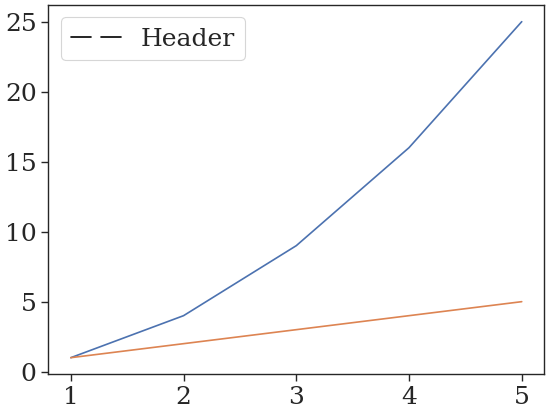

In [25]:
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

# Create some sample data
x = [1, 2, 3, 4, 5]
y1 = [1, 4, 9, 16, 25]
y2 = [1, 2, 3, 4, 5]

# Plot the data
plt.plot(x, y1, label='Data 1')
plt.plot(x, y2, label='Data 2')

# Create custom legend handles and labels
handles = [(plt.Line2D([], [], linestyle='-', color='black'), plt.Line2D([], [], linestyle='-', color='black'))]
labels = ['Header']

# Add the custom legend handler
plt.legend([tuple(handles[0])], [labels[0]], handler_map={tuple: HandlerTuple(ndivide=None)})

plt.show()